<a href="https://colab.research.google.com/github/cahyoadi88/Script/blob/main/DECISION_TREE_LOAN_REPAYMENT_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IMPORT LIBRARY

- import pandas as pd: Library pandas digunakan untuk manipulasi dan analisis data. 
- import requests: Library requests digunakan untuk mengirim permintaan HTTP. 
- from sklearn.model_selection import train_test_split: Fungsi train_test_split dari library sklearn.model_selection digunakan untuk membagi dataset menjadi subset train dan test. Ini membantu dalam melakukan evaluasi model dengan memisahkan data yang digunakan untuk melatih model dan data yang digunakan untuk menguji model. 
- from sklearn.tree import DecisionTreeClassifier: DecisionTreeClassifier adalah sebuah kelas di library sklearn.tree yang digunakan untuk membangun model Decision Tree untuk klasifikasi. 
- from sklearn.metrics import accuracy_score: Fungsi accuracy_score dari library sklearn.metrics digunakan untuk menghitung akurasi model klasifikasi.
- from sklearn.tree import plot_tree: Fungsi plot_tree dari library sklearn.tree digunakan untuk memvisualisasikan model Decision Tree. 
- import matplotlib.pyplot as plt: Library matplotlib.pyplot digunakan untuk membuat visualisasi grafik dan plot. Dalam konteks ini, matplotlib.pyplot digunakan untuk menampilkan plot dari model Decision Tree yang dihasilkan.

In [1]:
import pandas as pd
import requests  
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

#IMPORT DATASET


Dataset "USE REPAYMENT LOAN" merupakan dataset yang berkaitan dengan prediksi pembayaran pinjaman oleh pelanggan. Problem statement yang diberikan adalah untuk memprediksi apakah pelanggan akan membayar jumlah pinjaman atau tidak menggunakan algoritma pohon keputusan dengan Python.

In [2]:
file_url = "https://drive.google.com/u/0/uc?id=1yMCvWtr5nKkpZ4LM21iGCEvx-iVDLaPf&export=download"
file_name = "balance_data"

response = requests.get(file_url)
open(file_name, "wb").write(response.content)
balance_data = pd.read_csv('/content/balance_data',sep='\t')

In [3]:
balance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Initial payment  1000 non-null   int64 
 1   Last payment     1000 non-null   int64 
 2   Credit Score     1000 non-null   int64 
 3   House Number     1000 non-null   int64 
 4   Result           1000 non-null   object
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


Dataset "LOAN REPAYMENT PREDICTION" mencakup beberapa atribut yang berkaitan dengan prediksi pembayaran pinjaman. Berikut adalah penjelasan tentang tiap atribut dalam dataset tersebut:

1. Initial Payment:

Ini adalah atribut yang menunjukkan jumlah pembayaran awal yang telah dibayarkan oleh peminjam pada saat mengambil pinjaman.

2. Last Payment:

Atribut ini menunjukkan jumlah pembayaran terakhir yang telah dibayarkan oleh peminjam dalam periode tertentu. Nilai atribut ini juga dapat berupa jumlah uang 

3. Credit Score:

Credit score adalah skor numerik yang mencerminkan keandalan kredit peminjam.
Skor kredit biasanya diberikan oleh lembaga kredit berdasarkan riwayat kredit peminjam, termasuk riwayat pembayaran pinjaman sebelumnya, keterlambatan pembayaran, dan faktor-faktor lainnya.
Skor kredit yang lebih tinggi menunjukkan reputasi kredit yang lebih baik dan kemungkinan yang lebih tinggi untuk membayar kembali pinjaman.

4. House Number:

Atribut ini mungkin merujuk pada nomor identifikasi atau nomor rumah yang terkait dengan peminjam.
Ini bisa menjadi atribut yang digunakan untuk mengidentifikasi secara unik peminjam dalam dataset

5. Result:

Atribut ini mungkin menunjukkan hasil dari prediksi atau penilaian terhadap kemungkinan pembayaran pinjaman oleh peminjam.
Nilai atribut ini dapat berupa "Yes" atau "No" untuk menunjukkan apakah peminjam kemungkinan akan membayar kembali pinjaman atau tidak.

In [ ]:
balance_data.head()

,Initial payment,Last payment,Credit Score,House Number,Result
0,201,10018,250,3046,yes
1,205,10016,395,3044,yes
2,257,10129,109,3251,yes
3,246,10064,324,3137,yes
4,117,10115,496,3094,yes


In [ ]:
balance_data.tail()

,Initial payment,Last payment,Credit Score,House Number,Result
995,413,14914,523,4683,No
996,359,14423,927,4838,No
997,316,14872,613,4760,No
998,305,14926,897,4572,No
999,168,14798,834,4937,No


#SPLIT DATA

In [4]:
X = balance_data.drop(['Result'],axis=1)
y = balance_data['Result']

In [5]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.3, random_state = 100)

#LATIH MODEL DECISION TREE


In [ ]:
#Using the Decision Tree Classifier with splitting criterion as Gini impurity, the maximum depth of the tree is 3.
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3)


# fit the model
clf_gini.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

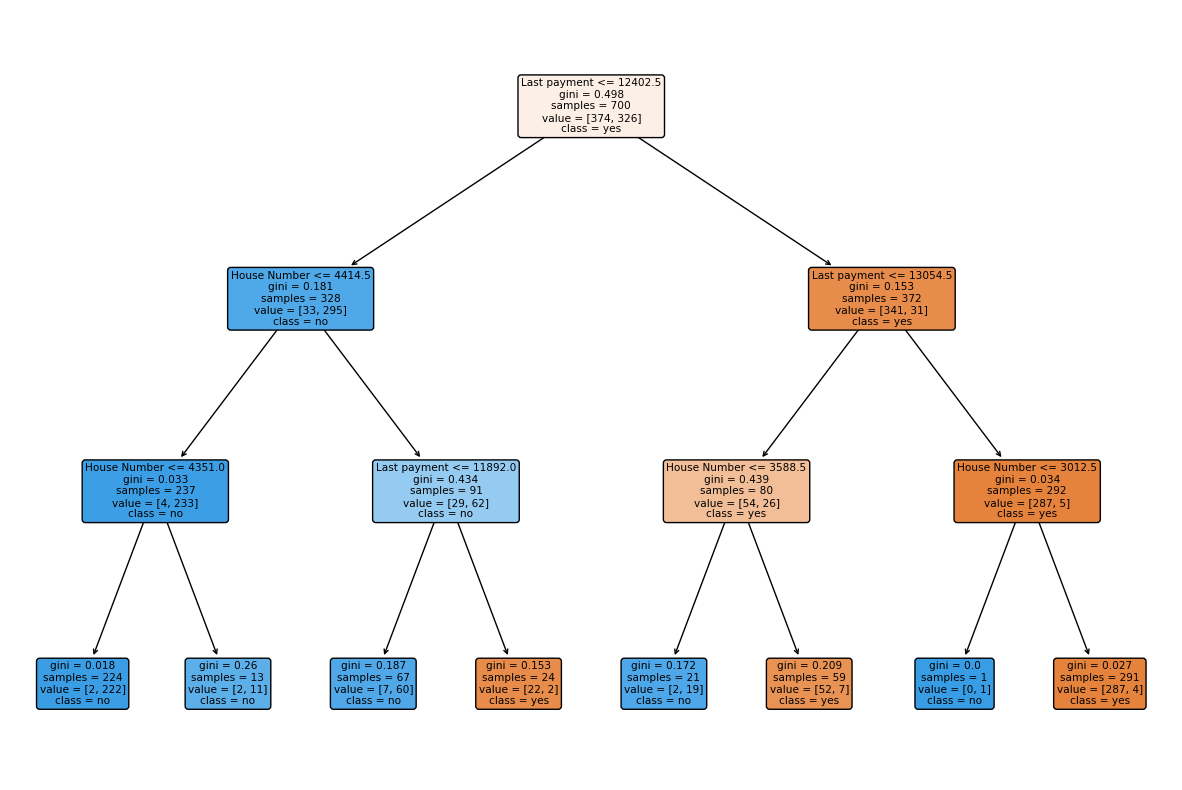

In [ ]:

fig, ax = plt.subplots(figsize=(15, 10))
plot_tree(clf_gini, feature_names=['Initial payment', 'Last payment', 'Credit Score', 'House Number'], 
          class_names=['yes','no' ],
          rounded= True,
          filled=True)
plt.show()

In [ ]:
# prediksi model dengan tree_model.predict([[SepalLength, SepalWidth, PetalLength, PetalWidth]])
print(clf_gini.predict([[168	, 13798		, 400, 8094	]])[0])

No


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


#EVALUASI AKURASI MODEL

In [ ]:
#Predict the values 
y_pred_gini = clf_gini.predict(X_test)
#Determine the accuracy score
print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score with criterion gini index: 0.9467
